
  Ulises Alarcón 21.543.468-0
  Programacion Cientifica - Caso 2

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df = pd.read_csv('Titanic-Dataset.xls')

In [84]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [85]:
columnas_español = {
    'PassengerId': 'Id_Pasajero',
    'Survived': 'Superviviente',
    'Pclass': 'Clase_Pasaje',
    'Name': 'Nombre',
    'Sex': 'Genero',
    'Age': 'Edad',
    'SibSp': 'Hermanos_Esposos',
    'Parch': 'Padres_Hijos',
    'Ticket': 'Boleto',
    'Fare': 'Tarifa',
    'Cabin': 'Camarote',
    'Embarked': 'Puerto_Embarque'
}

df = df.rename(columns=columnas_español)

In [86]:
df.shape

(891, 12)

In [87]:
df.head()

,Id_Pasajero,Superviviente,Clase_Pasaje,Nombre,Genero,Edad,Hermanos_Esposos,Padres_Hijos,Boleto,Tarifa,Camarote,Puerto_Embarque
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
df.tail()

,Id_Pasajero,Superviviente,Clase_Pasaje,Nombre,Genero,Edad,Hermanos_Esposos,Padres_Hijos,Boleto,Tarifa,Camarote,Puerto_Embarque
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id_Pasajero       891 non-null    int64  
 1   Superviviente     891 non-null    int64  
 2   Clase_Pasaje      891 non-null    int64  
 3   Nombre            891 non-null    object 
 4   Genero            891 non-null    object 
 5   Edad              714 non-null    float64
 6   Hermanos_Esposos  891 non-null    int64  
 7   Padres_Hijos      891 non-null    int64  
 8   Boleto            891 non-null    object 
 9   Tarifa            891 non-null    float64
 10  Camarote          204 non-null    object 
 11  Puerto_Embarque   889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [90]:
df.describe()

,Id_Pasajero,Superviviente,Clase_Pasaje,Edad,Hermanos_Esposos,Padres_Hijos,Tarifa
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [91]:
df.isnull().sum()

Id_Pasajero           0
Superviviente         0
Clase_Pasaje          0
Nombre                0
Genero                0
Edad                177
Hermanos_Esposos      0
Padres_Hijos          0
Boleto                0
Tarifa                0
Camarote            687
Puerto_Embarque       2
dtype: int64

In [92]:
df.isna().mean()*100

Id_Pasajero          0.000000
Superviviente        0.000000
Clase_Pasaje         0.000000
Nombre               0.000000
Genero               0.000000
Edad                19.865320
Hermanos_Esposos     0.000000
Padres_Hijos         0.000000
Boleto               0.000000
Tarifa               0.000000
Camarote            77.104377
Puerto_Embarque      0.224467
dtype: float64

In [93]:
df['Edad'] = df.groupby('Clase_Pasaje')['Edad'].transform(lambda x: x.fillna(x.median()))

In [94]:
df['Puerto_Embarque'] = df['Puerto_Embarque'].fillna(df['Puerto_Embarque'].mode()[0])

In [95]:
df.isna().sum()

Id_Pasajero           0
Superviviente         0
Clase_Pasaje          0
Nombre                0
Genero                0
Edad                  0
Hermanos_Esposos      0
Padres_Hijos          0
Boleto                0
Tarifa                0
Camarote            687
Puerto_Embarque       0
dtype: int64

In [96]:
edad_por_clase = df.groupby('Clase_Pasaje')['Edad'].agg(['mean', 'count'])
edad_por_clase = edad_por_clase.rename(columns={
    'mean': 'Promedio',
    'count': 'Contados'
})
print(edad_por_clase)

               Promedio  Contados
Clase_Pasaje                     
1             38.062130       216
2             29.825163       184
3             24.824684       491


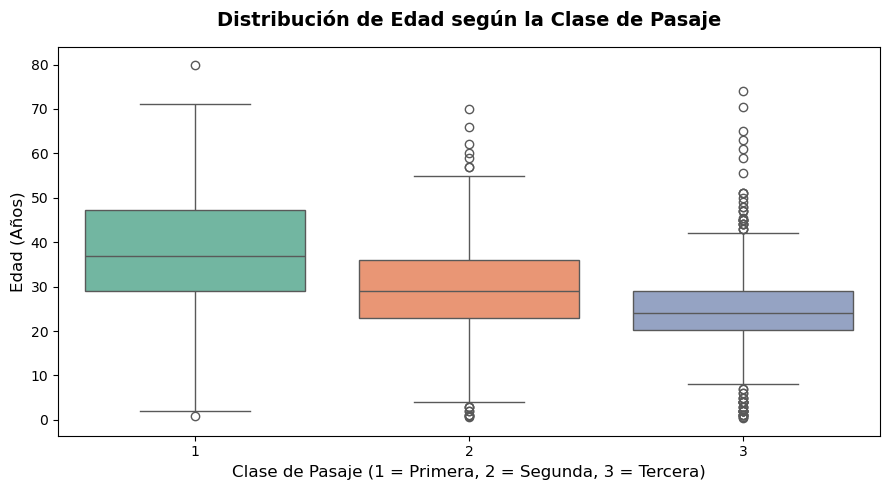

In [97]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Clase_Pasaje', y='Edad', hue='Clase_Pasaje', data=df, palette='Set2', legend=False)
plt.title('Distribución de Edad según la Clase de Pasaje', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Clase de Pasaje (1 = Primera, 2 = Segunda, 3 = Tercera)', fontsize=12)
plt.ylabel('Edad (Años)', fontsize=12)
plt.tight_layout()
plt.savefig('distribucion de edad segun la clase de pasaje.png', dpi=300)
plt.show()

In [98]:
df['Tamaño_Familia'] = df['Hermanos_Esposos'] + df['Padres_Hijos'] + 1
familia_por_clase = df.groupby('Clase_Pasaje')['Tamaño_Familia'].mean().reset_index()
print(familia_por_clase)

   Clase_Pasaje  Tamaño_Familia
0             1        1.773148
1             2        1.782609
2             3        2.008147


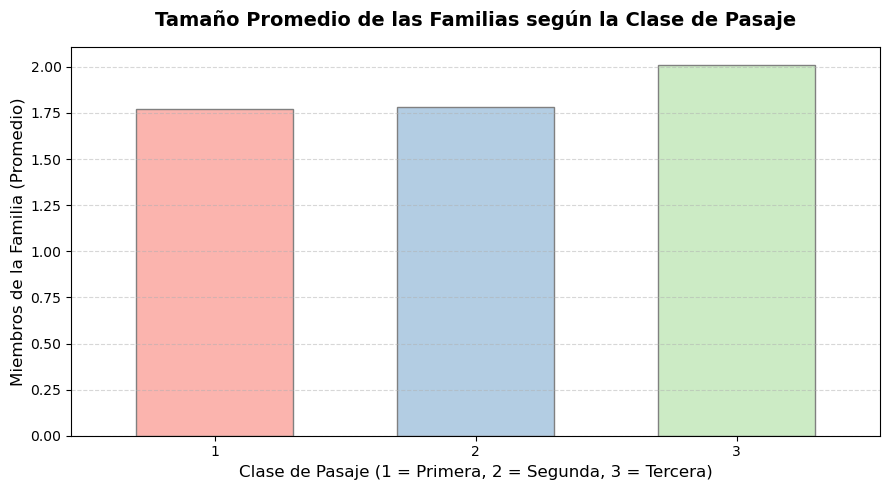

In [99]:
plt.figure(figsize=(9, 5))


df.groupby('Clase_Pasaje')['Tamaño_Familia'].mean().plot(
    kind='bar', 
    color=['#fbb4ae', '#b3cde3', '#ccebc5'], 
    edgecolor='gray', 
    width=0.6,
    rot=0 
)

plt.title('Tamaño Promedio de las Familias según la Clase de Pasaje', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Clase de Pasaje (1 = Primera, 2 = Segunda, 3 = Tercera)', fontsize=12)
plt.ylabel('Miembros de la Familia (Promedio)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tamaño promedio de familias segun la clase.png', dpi=300)

plt.show()

In [100]:
tarifas_por_clase = df.groupby('Clase_Pasaje')['Tarifa'].agg(['mean', 'median', 'min', 'max'])
tarifas_por_clase = tarifas_por_clase.rename(columns={
    'mean': 'Promedio',
    'median': 'Mediana',
    'min': 'Mínimo',
    'max': 'Máximo'
})
print(tarifas_por_clase)

               Promedio  Mediana  Mínimo    Máximo
Clase_Pasaje                                      
1             84.154687  60.2875     0.0  512.3292
2             20.662183  14.2500     0.0   73.5000
3             13.675550   8.0500     0.0   69.5500


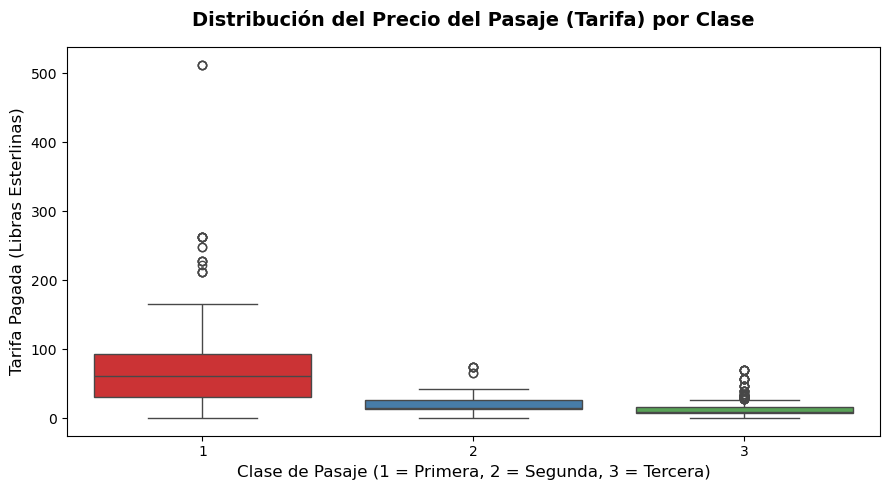

In [101]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    x='Clase_Pasaje', 
    y='Tarifa', 
    hue='Clase_Pasaje', 
    data=df, 
    palette='Set1', 
    legend=False
)

plt.title('Distribución del Precio del Pasaje (Tarifa) por Clase', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Clase de Pasaje (1 = Primera, 2 = Segunda, 3 = Tercera)', fontsize=12)
plt.ylabel('Tarifa Pagada (Libras Esterlinas)', fontsize=12)

plt.tight_layout()
plt.savefig('tarifa promedio segun la clase.png', dpi=300)
plt.show()

In [102]:
def detectar_outliers_iqr(dataframe, columna):
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    
    print(f"--- Análisis de Outliers para la columna: '{columna}' ---")
    print(f"Límite Inferior Estadístico: {limite_inferior:.2f}")
    print(f"Límite Superior Estadístico: {limite_superior:.2f}")
    print(f"Cantidad total de valores atípicos detectados: {len(outliers)}")
    print(f"Porcentaje de datos atípicos: {(len(outliers) / len(dataframe)) * 100:.2f}%")
    
    return outliers

In [103]:
outliers_tarifa = detectar_outliers_iqr(df, 'Tarifa')

--- Análisis de Outliers para la columna: 'Tarifa' ---
Límite Inferior Estadístico: -26.72
Límite Superior Estadístico: 65.63
Cantidad total de valores atípicos detectados: 116
Porcentaje de datos atípicos: 13.02%


In [104]:
outliers_edad = detectar_outliers_iqr(df, 'Edad')

--- Análisis de Outliers para la columna: 'Edad' ---
Límite Inferior Estadístico: -0.50
Límite Superior Estadístico: 59.50
Cantidad total de valores atípicos detectados: 26
Porcentaje de datos atípicos: 2.92%
